Import Flattened STM Data:

STM_Device 115_g 10K_2019_10_11_17_03_18_195 Image Topography


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import pybinding as pb

from scipy.ndimage import rotate
from scipy.interpolate import griddata
from pybinding.repository import graphene

In [2]:
pth = r"/home/cmp/Documents/Github/QPI-Scattering/ExperimentAnalysis/Data/STM195XYZ.txt"
df = pd.read_table(pth, skiprows=3, sep='\t', header=None, names=['X', 'Y', 'Z'])
df.head()

,X,Y,Z
0,0.000000,0.0,1.110560e-10
1,0.058796,0.0,1.173700e-10
2,0.117592,0.0,1.250250e-10
3,0.176388,0.0,1.240050e-10
4,0.235183,0.0,1.235580e-10


In [3]:
X = df['X'].values
Y = df['Y'].values
Z = df['Z'].values * 1e9

In [4]:
print(X.shape)

(84681,)


In [5]:
# Creating a uniform grid and interpolating
N = 1000
grid_x, grid_y = np.meshgrid(
    np.linspace(min(X), max(X), N),
    np.linspace(min(Y), max(Y), N)
)

# Interpolate Z values on the grid
grid_z = griddata((X, Y), Z, (grid_x, grid_y), method='linear')

In [6]:
# Rotate Data for better comparision with analytical work
zrot = np.rot90(grid_z, k=3)

Text(0.5, 1.0, 'STM_Device 115_g \n10K_2019_10_11_17_03_18_195 Image Topography\n sep: 2.5495 nm or 9.3659 unitcells')

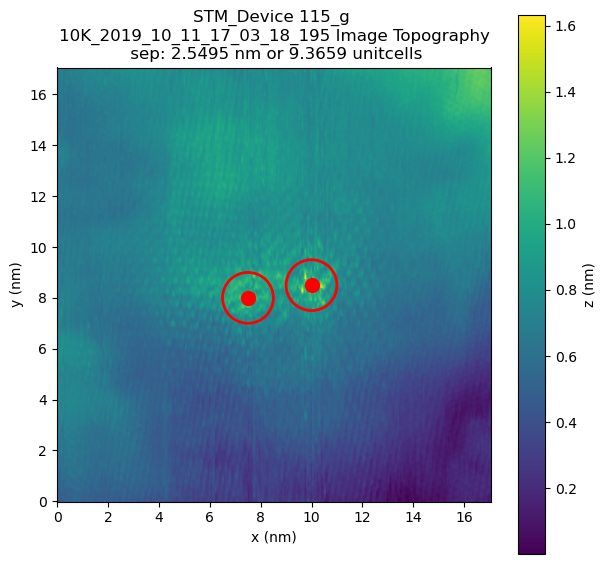

In [7]:
fig, ax = plt.subplots(figsize=(7, 7))

pc = ax.pcolormesh(grid_x, grid_y, zrot)
fig.colorbar(pc, label="z (nm)")
ax.set_aspect('equal')
ax.set_xlabel('x (nm)')
ax.set_ylabel('y (nm)')

#ax.set_xlim(6, 12)
#ax.set_ylim(5, 11)

# Nailing down location of possible two point defects
R1x, R1y = 7.5, 8
R2x, R2y = 10, 8.5
r1, r2 = 1, 1

c1 = patches.Circle((R1x, R1y), r1, linewidth=2, fill=False, edgecolor='red')
c2 = patches.Circle((R2x, R2y), r2, linewidth=2, fill=False, edgecolor='red')

ax.scatter([R1x, R2x], [R1y, R2y], c="red", s=100)
ax.add_patch(c1)
ax.add_patch(c2)

sepNM = np.sqrt((R1x - R2x) ** 2 + (R1y - R2y) ** 2)

a_cc = 0.142 #nm
h = a_cc * np.tan(np.pi/3)

seph = sepNM / h

ax.set_title(f'STM_Device 115_g \n10K_2019_10_11_17_03_18_195 Image Topography' + \
f'\n sep: {sepNM:.4f} nm or {seph-1:.4f} unitcells')

In [21]:
np.rad2deg(np.atan((R2y-R1y)/(R2x-R1x)))

np.float64(11.309932474020215)

0 -0.07099964935359424
2.4595121467478047 -0.3549982467679712
Norm
2.4758544390438884
Deg
-6.5867433094935635


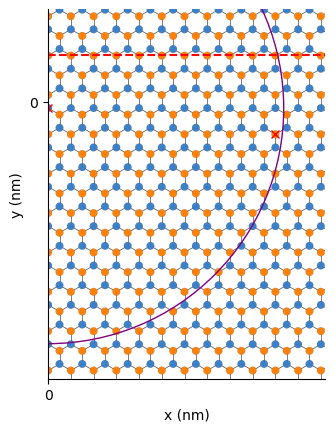

In [96]:
# Figure out location of defects
model = pb.Model(graphene.monolayer(), pb.rectangle(20, 20))

at = graphene.a/np.sqrt(3) # Distance between A and B sublattices

model.plot()
ax = plt.gca()

ax.set_xlim(0, 3)
ax.set_ylim(-3, 1)

#Change in y from above is about 0.5 nm
ax.axhline(0.5, c="r", linestyle="dashed")


ax.plot(0, -at/2, 'r', marker="x")

n0 = 8
n1 = 1

d2x = 10*h
d2y = -5* at/2

print(0, -at/2)
print(d2x, d2y)

print("Norm")
print(np.sqrt(d2x **2 + (-at/2 - d2y) ** 2))

CR = patches.Circle((0, -at/2), radius=sepNM, ec='purple', fill=False)

ax.plot(d2x, d2y, 'r', marker="x")
ax.add_patch(CR)

print("Deg")
print(np.rad2deg(np.atan2(-1*(-at/2 - d2y), -1*(0-d2x))))

FFT

In [9]:
# Periodic 1D Hann Function
def hann1dp(x, N, x0):
    return np.cos(np.pi * (x-x0)/N) ** 2

def hann2d(x, y, Nx, Ny, x0, y0): 
    val = hann1dp(x, Nx, x0) * hann1dp(y, Ny, y0)

    return np.where((np.abs(x-x0) <= 0.5 * Nx) & (np.abs(y-y0) <= 0.5 * Ny), val, 0)

hann_vec = np.vectorize(hann2d)

In [10]:
def RotateVec(th):
    mx = np.array([
        [np.cos(th), -np.sin(th)],
        [np.sin(th), np.cos(th)]
    ])

    return mx

(-50.0, 50.0)

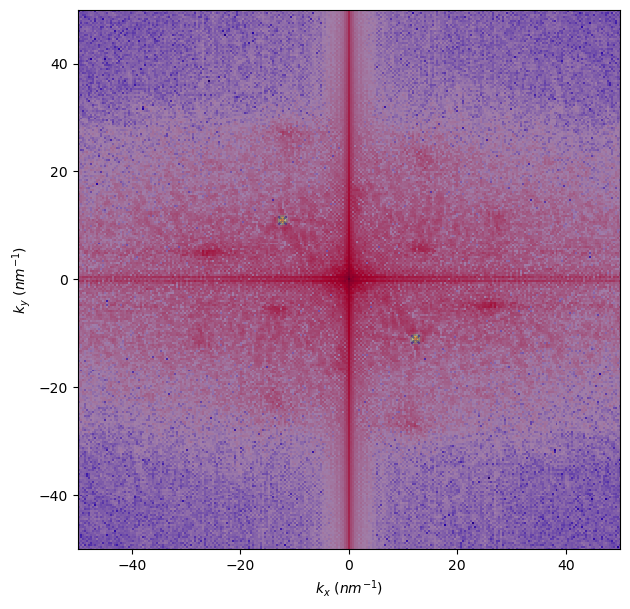

In [11]:
# Perform 2D FFT
ft = np.fft.fft2(zrot)
fts = np.fft.fftshift(ft)

# Wavenumber axes
xlin = np.linspace(min(X), max(X), N)
dx = xlin[1] - xlin[0]
kx = np.fft.fftshift(np.fft.fftfreq(N, d=dx)) * 2 * np.pi  # cycles/m → radians/m

# Create 2D wavenumber grids
KX, KY = np.meshgrid(kx, kx)

fig1, ax1 = plt.subplots(figsize=(7, 7))
ax1.pcolormesh(KX, KY, np.log(np.abs(fts)), cmap='seismic')
ax1.set_xlabel("$k_x ~(nm^{-1})$")
ax1.set_ylabel("$k_y ~(nm^{-1})$")

fp1x, fp1y, fr1 = -12.25, 11, 1.5
fp2x, fp2y, fr2 = 12.25, -11, fr1

ax1.scatter([fp1x, fp2x], [fp1y, fp2y], color='purple', marker="x")

hz = hann2d(KX, KY, 2 * fr1, 2 * fr1, fp1x, fp1y) + hann2d(KX, KY, 2 * fr2, 2 * fr2, fp2x, fp2y)

ax1.pcolormesh(KX, KY,hz, alpha=0.5)

ax1.set_xlim(-50, 50)
ax1.set_ylim(-50, 50)

In [19]:
np.atan2(11, -12.25)
np.rad2deg(np.atan2(11, -12.25))

np.float64(138.0774553994244)

In [12]:
# Apply Filter
ftzf = fts * hz
# IFT
zf = np.fft.ifft2(ftzf)

Text(0.5, 1.0, 'STM_Device 115_g \n10K_2019_10_11_17_03_18_195 Filtered\n sep: 2.5495 nm or 9.3659 unitcells')

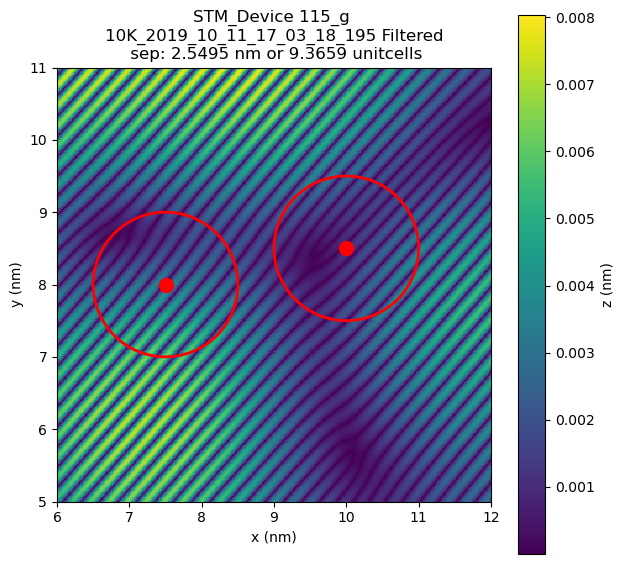

In [13]:
fig3, ax3 = plt.subplots(figsize=(7, 7))

pc3 = ax3.pcolormesh(grid_x, grid_y, np.abs(zf))
fig3.colorbar(pc3, label="z (nm)")
ax3.set_aspect('equal')
ax3.set_xlabel('x (nm)')
ax3.set_ylabel('y (nm)')

ax3.scatter([R1x, R2x], [R1y, R2y], c="red", s=100)

c13 = patches.Circle((R1x, R1y), r1, linewidth=2, fill=False, edgecolor='red')
c23 = patches.Circle((R2x, R2y), r2, linewidth=2, fill=False, edgecolor='red')

ax3.add_patch(c13)
ax3.add_patch(c23)

ax3.set_xlim(6, 12)
ax3.set_ylim(5, 11)

ax3.set_title(f'STM_Device 115_g \n10K_2019_10_11_17_03_18_195 Filtered' + \
f'\n sep: {sepNM:.4f} nm or {seph-1:.4f} unitcells')

##CHECK NORMALIZATION ON HANN FILTER##